In [18]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the directory where the notebook is located
notebook_path = os.getcwd()
file_path = os.path.join(notebook_path, "processed_capability_results", "capability_results.csv")

# Print it to verify it looks correct in the output
print(f"Looking for file at: {file_path}")

# '..' tells Python to go up one level from the 'analysis' folder to the project root
file_path = os.path.join("..", "processed_capability_results", "capability_results.csv")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    # Display name in plots (CSV still uses legacy label)
    df.loc[df["model"] == "Shape" + "FBT", "model"] = "FB-SGT"
    print("Success! File loaded.")
else:
    # If it still fails, let's see exactly where it is looking
    print(f"Still can't find it. Absolute path attempted: {os.path.abspath(file_path)}")

Looking for file at: /Users/beliz/Desktop/thesis_project/SagiXGBoostTreeApproximator/analysis/processed_capability_results/capability_results.csv
Success! File loaded.


### 1. The Core Comparison (Line Plots)

This cell creates a three-panel figure for a specific dataset. It uses sns.lineplot to automatically handle the averaging over our folds and trials, providing a shaded 95% confidence interval.

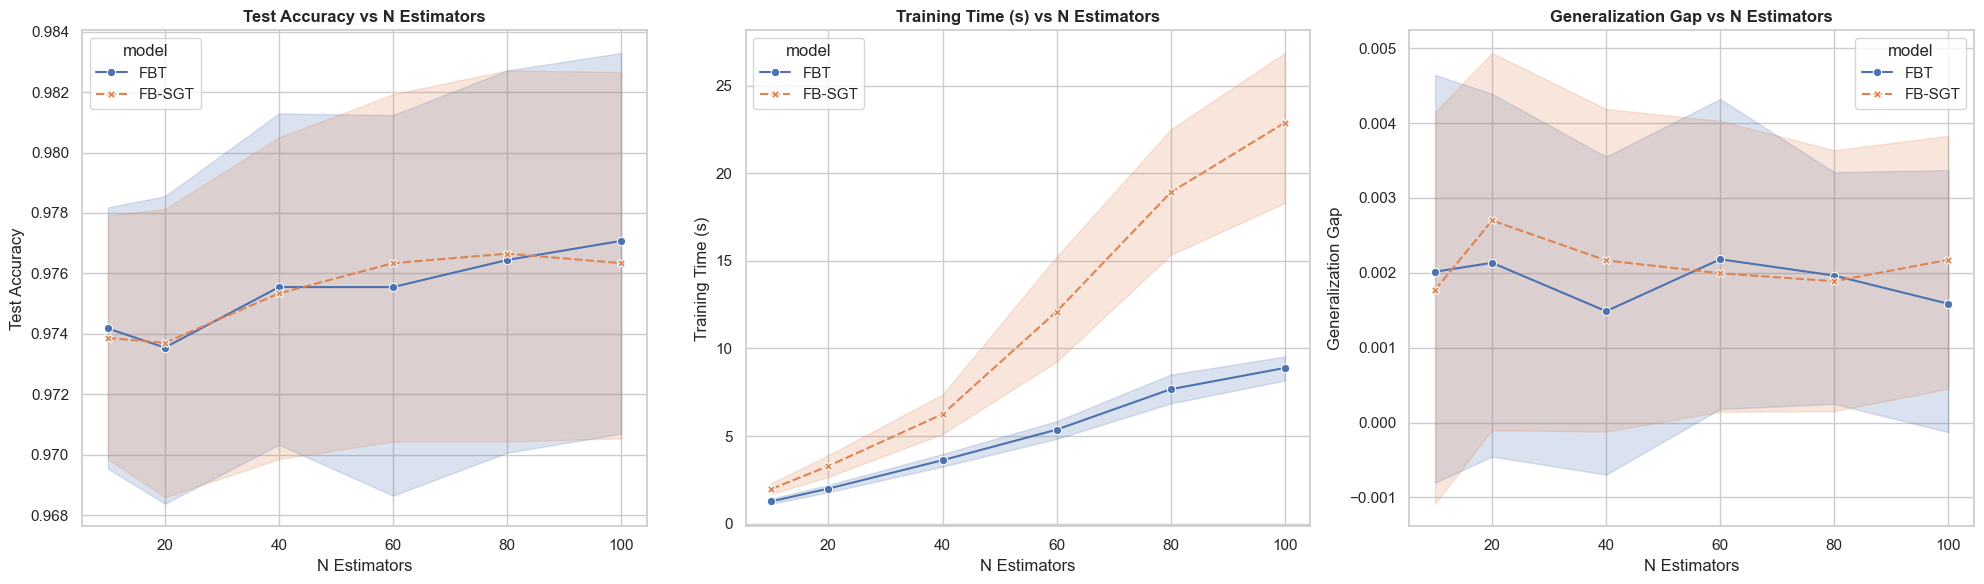

In [19]:
# Change this to the dataset you want to inspect
target_dataset = "bidding" 

# Filter data
plot_df = df[df['dataset'] == target_dataset]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ['test_acc', 'elapsed_time', 'generalization_gap']
titles = ['Test Accuracy', 'Training Time (s)', 'Generalization Gap']

for ax, metric, title in zip(axes, metrics, titles):
    sns.lineplot(
        data=plot_df, 
        x='n_estimators', 
        y=metric, 
        hue='model', 
        style='model', 
        markers=True, 
        ax=ax
    )
    ax.set_title(f"{title} vs N Estimators", fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xlabel("N Estimators")

plt.tight_layout()
plt.show()

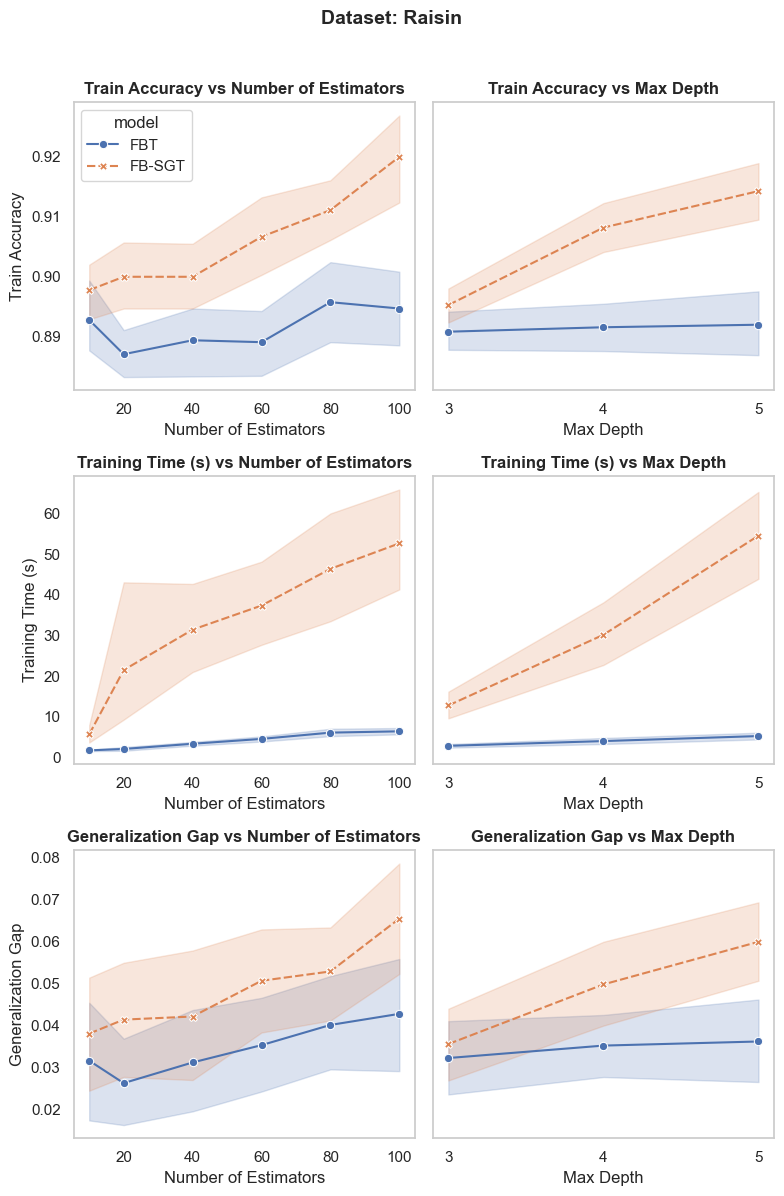

In [31]:
# Change this to the dataset you want to inspect
target_dataset = "raisin"

# Filter data
plot_df = df[df['dataset'] == target_dataset]

metrics = ['train_acc', 'elapsed_time', 'generalization_gap']
titles = ['Train Accuracy', 'Training Time (s)', 'Generalization Gap']

max_depth_xticks = sorted(int(x) for x in plot_df["max_depth"].dropna().unique())

# Left column: N Estimators, Right column: Max Depth
fig, axes = plt.subplots(3, 2, figsize=(8, 12), sharey='row')

for row_idx, (metric, title) in enumerate(zip(metrics, titles)):
    sns.lineplot(
        data=plot_df,
        x='n_estimators',
        y=metric,
        hue='model',
        style='model',
        markers=True,
        ax=axes[row_idx, 0],
        legend=(row_idx == 0)
    )
    axes[row_idx, 0].set_title(f"{title} vs Number of Estimators", fontweight='bold')
    axes[row_idx, 0].set_ylabel(title)
    axes[row_idx, 0].set_xlabel("Number of Estimators")
    axes[row_idx, 0].grid(False)

    sns.lineplot(
        data=plot_df,
        x='max_depth',
        y=metric,
        hue='model',
        style='model',
        markers=True,
        ax=axes[row_idx, 1],
        legend=False
    )
    axes[row_idx, 1].set_title(f"{title} vs Max Depth", fontweight='bold')
    axes[row_idx, 1].set_ylabel("")
    axes[row_idx, 1].set_xlabel("Max Depth")
    axes[row_idx, 1].set_xticks(max_depth_xticks)
    axes[row_idx, 1].grid(False)

fig.suptitle(f"Dataset: {target_dataset.capitalize()}", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


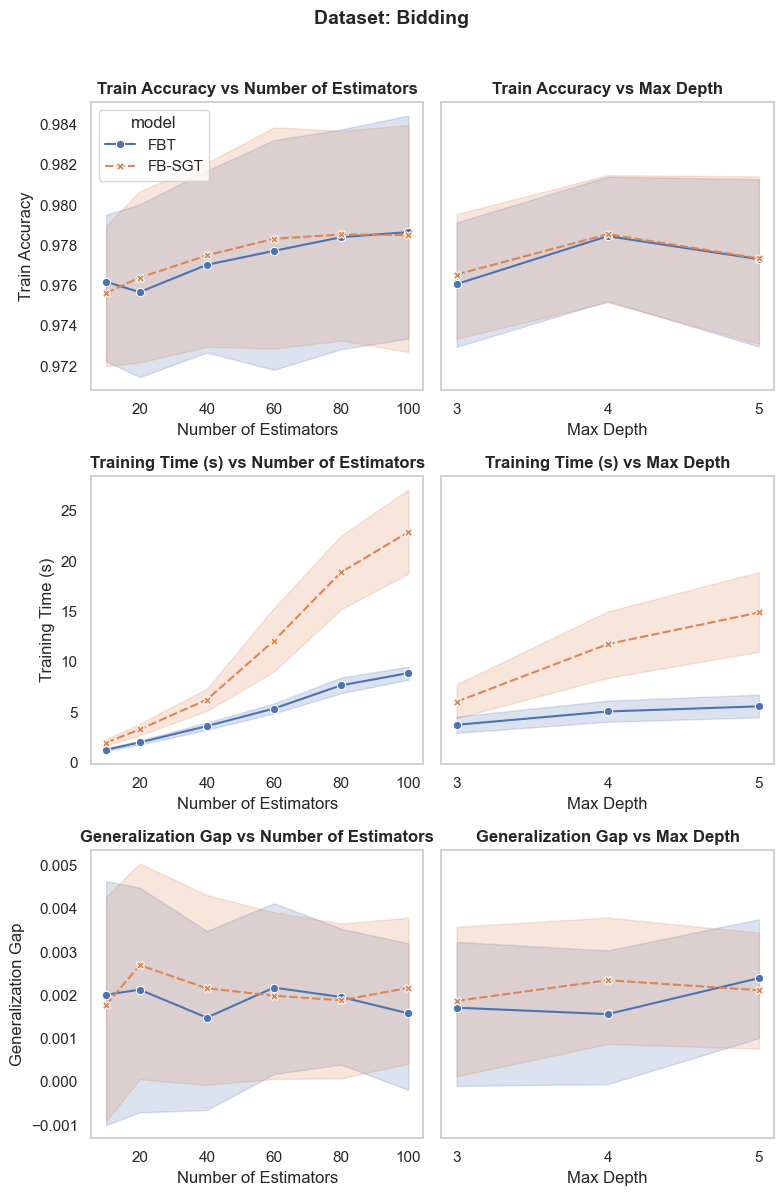

In [30]:
# Change this to the dataset you want to inspect
target_dataset = "bidding"

# Filter data
plot_df = df[df['dataset'] == target_dataset]

metrics = ['train_acc', 'elapsed_time', 'generalization_gap']
titles = ['Train Accuracy', 'Training Time (s)', 'Generalization Gap']

max_depth_xticks = sorted(int(x) for x in plot_df["max_depth"].dropna().unique())

# Left column: N Estimators, Right column: Max Depth
fig, axes = plt.subplots(3, 2, figsize=(8, 12), sharey='row')

for row_idx, (metric, title) in enumerate(zip(metrics, titles)):
    sns.lineplot(
        data=plot_df,
        x='n_estimators',
        y=metric,
        hue='model',
        style='model',
        markers=True,
        ax=axes[row_idx, 0],
        legend=(row_idx == 0)
    )
    axes[row_idx, 0].set_title(f"{title} vs Number of Estimators", fontweight='bold')
    axes[row_idx, 0].set_ylabel(title)
    axes[row_idx, 0].set_xlabel("Number of Estimators")
    axes[row_idx, 0].grid(False)

    sns.lineplot(
        data=plot_df,
        x='max_depth',
        y=metric,
        hue='model',
        style='model',
        markers=True,
        ax=axes[row_idx, 1],
        legend=False
    )
    axes[row_idx, 1].set_title(f"{title} vs Max Depth", fontweight='bold')
    axes[row_idx, 1].set_ylabel("")
    axes[row_idx, 1].set_xlabel("Max Depth")
    axes[row_idx, 1].set_xticks(max_depth_xticks)
    axes[row_idx, 1].grid(False)

fig.suptitle(f"Dataset: {target_dataset.capitalize()}", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


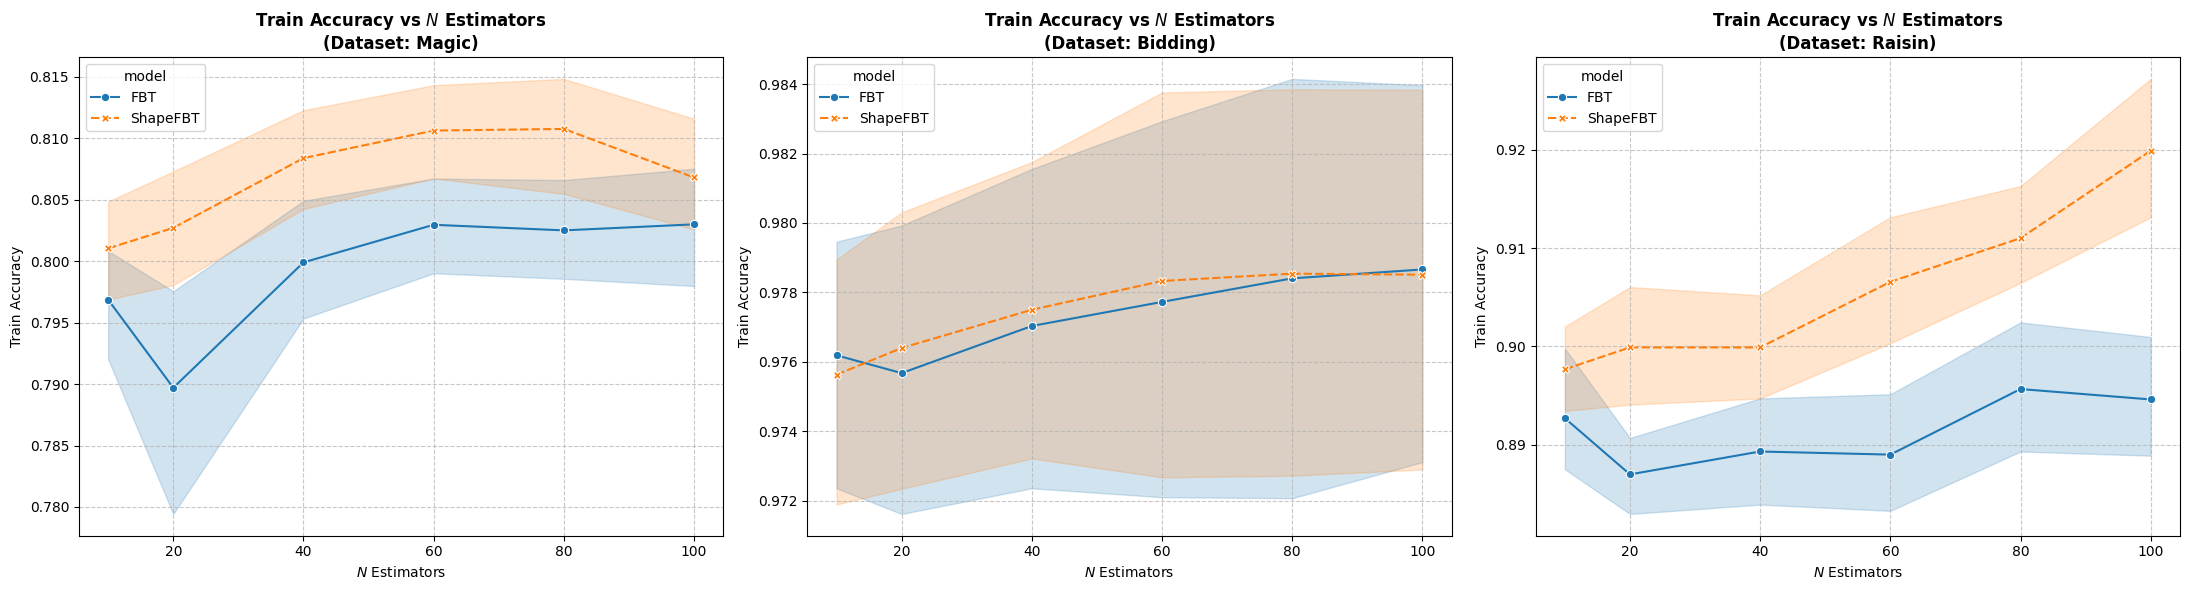

In [4]:
# Now we show all 3 datasets in one figure for both models (training acc vs n_estimators)
import matplotlib.pyplot as plt
import seaborn as sns

# List of datasets to plot
datasets = ['magic', 'bidding', 'raisin']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, dataset_name in zip(axes, datasets):
    # Filter data for the specific dataset in this subplot
    plot_df = df[df['dataset'] == dataset_name]
    
    sns.lineplot(
        data=plot_df, 
        x='n_estimators', 
        y='train_acc',  # Fixed to Training Accuracy
        hue='model', 
        style='model', 
        markers=True, 
        ax=ax
    )
    
    # Customize titles and labels
    ax.set_title(f"Train Accuracy vs $N$ Estimators\n(Dataset: {dataset_name.capitalize()})", fontweight='bold')
    ax.set_ylabel("Train Accuracy")
    ax.set_xlabel("$N$ Estimators")
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. Interaction Plot: How Max Depth affects Accuracy
A FacetGrid creates a separate subplot for each depth so you can see if FB-SGT scales better as trees get deeper.

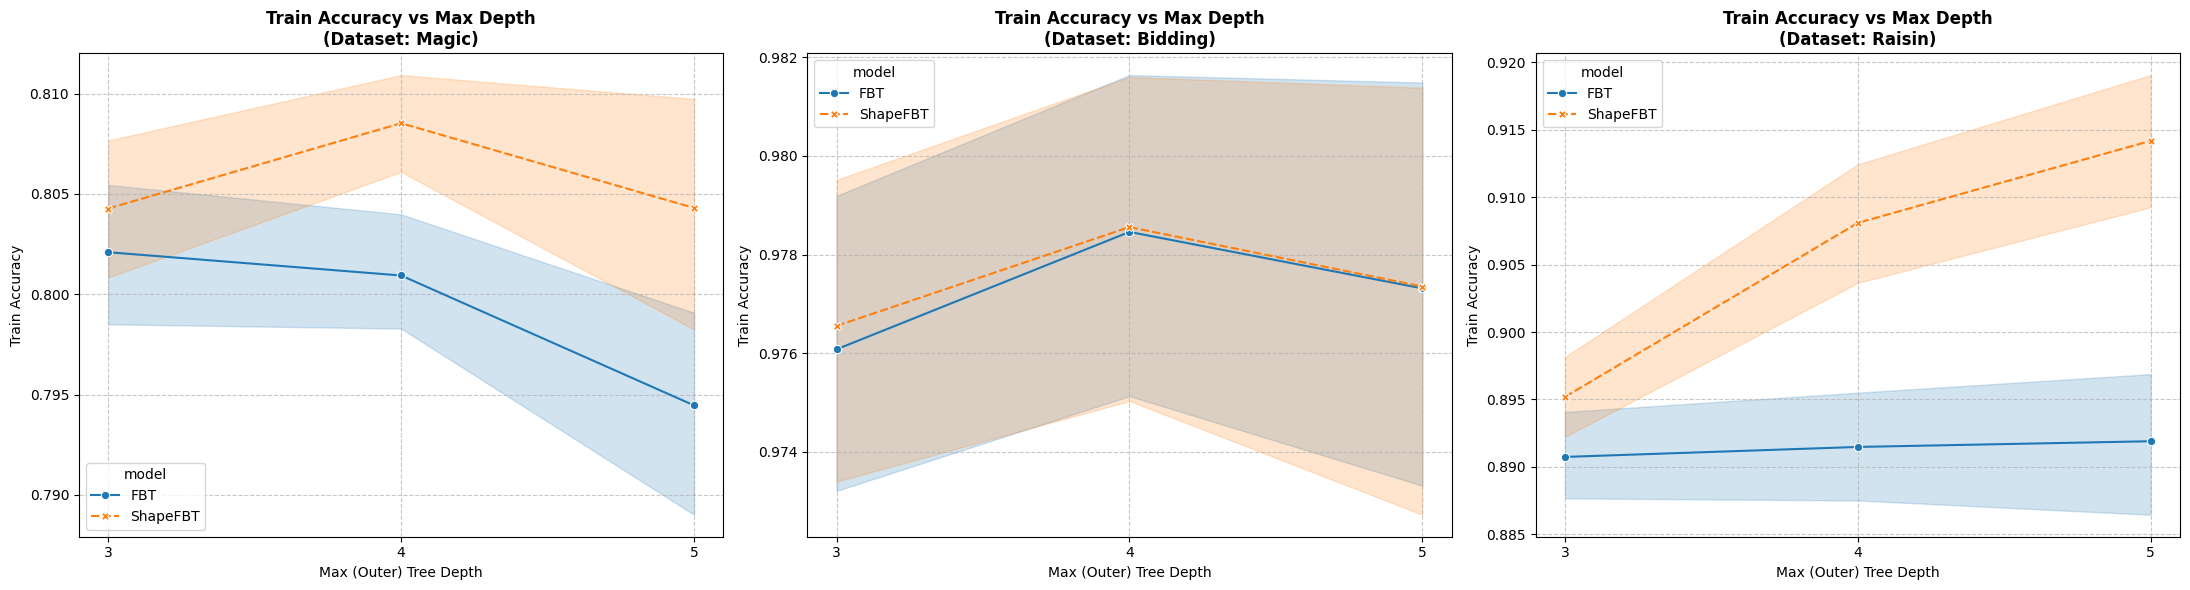

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# List of datasets to plot
datasets = ['magic', 'bidding', 'raisin']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, dataset_name in zip(axes, datasets):
    # Filter data for the specific dataset in this subplot
    plot_df = df[df['dataset'] == dataset_name]
    
    sns.lineplot(
        data=plot_df, 
        x='max_depth', 
        y='train_acc', 
        hue='model', 
        style='model', 
        markers=True, 
        ax=ax
    )
    
    # Force the x-axis to only show integer labels
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Optional: If you want every specific integer depth in your data to have a tick mark, 
    # use the line below instead:
    # ax.set_xticks(sorted(plot_df['max_depth'].unique().astype(int)))
    
    # Customize titles and labels
    ax.set_title(f"Train Accuracy vs Max Depth\n(Dataset: {dataset_name.capitalize()})", fontweight='bold')
    ax.set_ylabel("Train Accuracy")
    ax.set_xlabel("Max (Outer) Tree Depth")
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Yes, by default, sns.lineplot automatically aggregates data.

Since you are plotting max_depth on the x-axis and your dataframe contains multiple n_estimators values for each depth, Seaborn will calculate the mean (average) of the train_acc for all those points and display it as the main lin

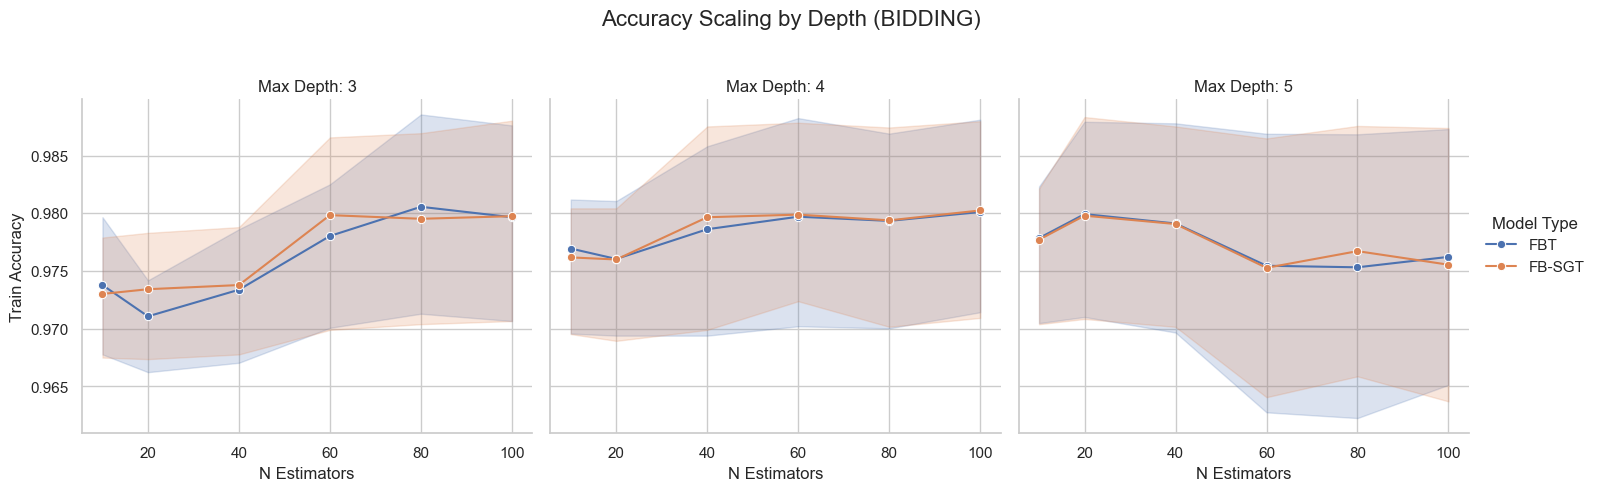

In [28]:
g = sns.FacetGrid(plot_df, col="max_depth", hue="model", height=5, aspect=1)
g.map(sns.lineplot, "n_estimators", "train_acc", marker="o")

g.add_legend(title="Model Type")
g.set_axis_labels("N Estimators", "Train Accuracy")
g.set_titles("Max Depth: {col_name}")

plt.subplots_adjust(top=0.8)
g.fig.suptitle(f"Accuracy Scaling by Depth ({target_dataset.upper()})", fontsize=16)
plt.show()

### 3. Efficiency Frontier

Motivation for this visualization: Sometimes a model with max_depth=3 and n_estimators=100 performs as well as max_depth=6 and n_estimators=10. Plotting these together helps you find the "cheapest" model (lowest time) that hits your accuracy target.

To make a clean Efficiency Frontier, we only care about the Pareto Optimal points. A point is Pareto optimal if there is no other point that is both faster and more accurate. So what we do is:

1. Group by Hyperparameters: Instead of plotting every trial/fold, we should plot the mean accuracy and mean time for each (n_estimators, max_depth) combination. 

2. Filter for the Frontier: Only connect the dots that actually represent an improvement (moving toward the top-left).

3. Separate the Lines: Instead of one messy line, we’ll draw one line per model that follows its best possible performance as time increases.

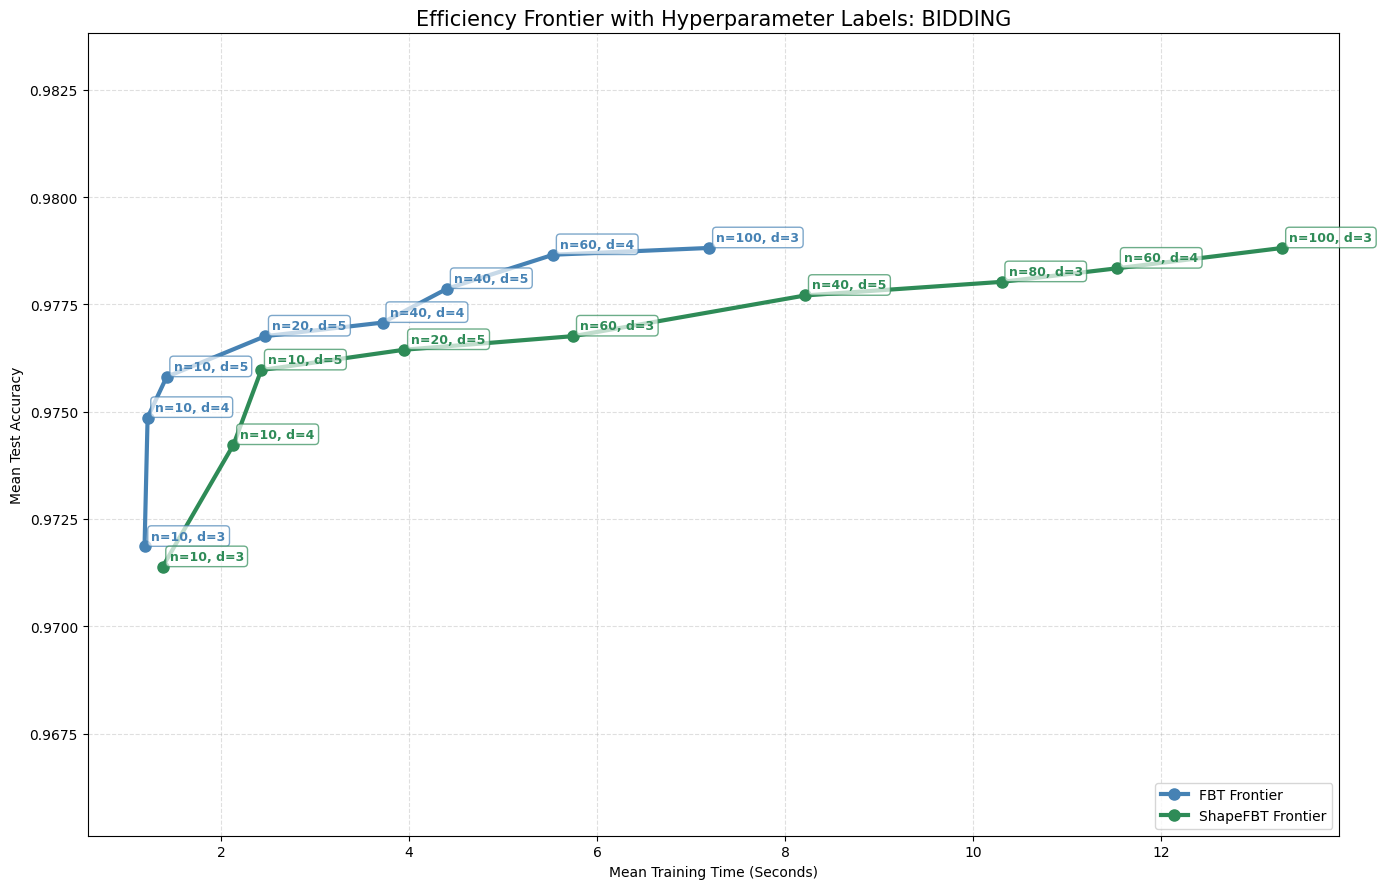

In [13]:
import numpy as np

def plot_annotated_frontier(df, target_dataset="bidding"):
    # 1. Aggregate to get means
    agg_df = df[df['dataset'] == target_dataset].groupby(
        ['model', 'n_estimators', 'max_depth']
    ).agg({'test_acc': 'mean', 'elapsed_time': 'mean'}).reset_index()

    plt.figure(figsize=(14, 9))
    colors = {'FBT': 'steelblue', 'FB-SGT': 'seagreen'}

    for model in agg_df['model'].unique():
        model_data = agg_df[agg_df['model'] == model].sort_values('elapsed_time')
        
        # 2. Calculate Frontier Points
        frontier_points = []
        current_max_acc = -np.inf
        
        for _, row in model_data.iterrows():
            if row['test_acc'] > current_max_acc:
                frontier_points.append(row)
                current_max_acc = row['test_acc']
        
        frontier_df = pd.DataFrame(frontier_points)

        # 3. Plot the Frontier Line
        line = plt.plot(frontier_df['elapsed_time'], frontier_df['test_acc'], 
                        label=f'{model} Frontier', color=colors[model], 
                        linewidth=3, marker='o', markersize=8)
        
        # 4. Annotate the Frontier Points
        for _, row in frontier_df.iterrows():
            label = f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}"
            
            plt.annotate(
                label, 
                xy=(row['elapsed_time'], row['test_acc']),
                xytext=(5, 5), # Offset text slightly
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color=colors[model],
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec=colors[model])
            )

    plt.title(f"Efficiency Frontier with Hyperparameter Labels: {target_dataset.upper()}", fontsize=15)
    plt.xlabel("Mean Training Time (Seconds)")
    plt.ylabel("Mean Test Accuracy")
    
    # Adjust y-axis to focus on the data range
    y_min = agg_df['test_acc'].min() - 0.005
    y_max = agg_df['test_acc'].max() + 0.005
    plt.ylim(y_min, y_max)
    
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_annotated_frontier(df)

### 4. Accuracy vs N Estimators Frontiers

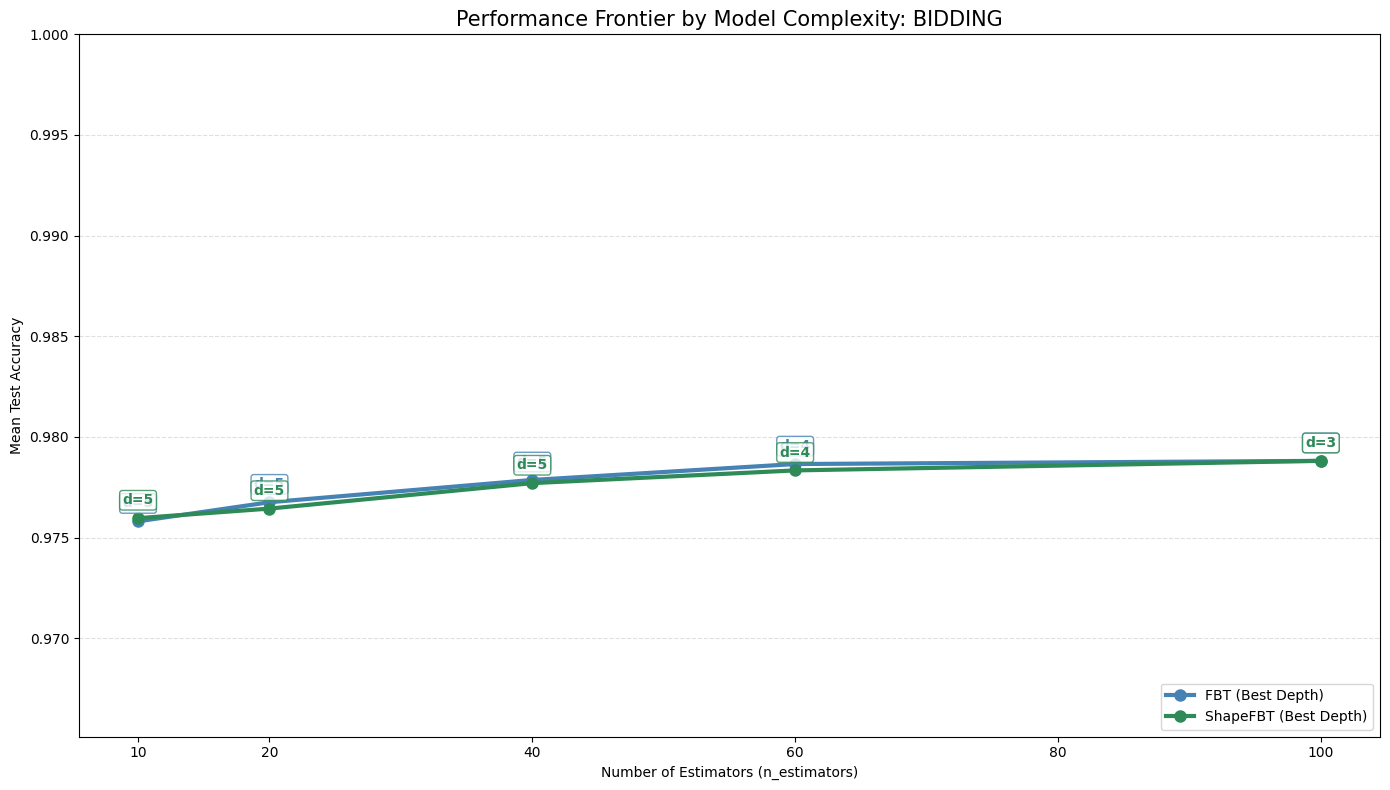

In [14]:
def plot_estimators_frontier(df, target_dataset="bidding"):
    # 1. Aggregate to get mean accuracy for each (model, n_estimators, max_depth)
    agg_df = df[df['dataset'] == target_dataset].groupby(
        ['model', 'n_estimators', 'max_depth']
    )['test_acc'].mean().reset_index()

    plt.figure(figsize=(14, 8))
    colors = {'FBT': 'steelblue', 'FB-SGT': 'seagreen'}

    for model in agg_df['model'].unique():
        model_data = agg_df[agg_df['model'] == model].sort_values('n_estimators')
        
        # 2. Find the best depth for each n_estimators value
        # This creates the "Upper Envelope" of performance
        frontier_points = []
        unique_estimators = sorted(model_data['n_estimators'].unique())
        
        current_max_acc = -np.inf
        
        for n in unique_estimators:
            # Get all depths for this specific n_estimators
            options = model_data[model_data['n_estimators'] == n]
            best_row = options.loc[options['test_acc'].idxmax()]
            
            # Pareto check: Only add if it's better or equal to what we've seen 
            # (prevents the line from dipping if a larger ensemble overfits)
            if best_row['test_acc'] >= current_max_acc:
                frontier_points.append(best_row)
                current_max_acc = best_row['test_acc']
        
        frontier_df = pd.DataFrame(frontier_points)

        # 3. Plot the Frontier Line
        plt.plot(frontier_df['n_estimators'], frontier_df['test_acc'], 
                 label=f'{model} (Best Depth)', color=colors[model], 
                 linewidth=3, marker='o', markersize=8)
        
        # 4. Annotate with the winning Max Depth
        for _, row in frontier_df.iterrows():
            plt.annotate(
                f"d={int(row['max_depth'])}", 
                xy=(row['n_estimators'], row['test_acc']),
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color=colors[model],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec=colors[model])
            )

    plt.title(f"Performance Frontier by Model Complexity: {target_dataset.upper()}", fontsize=15)
    plt.xlabel("Number of Estimators (n_estimators)")
    plt.ylabel("Mean Test Accuracy")
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.xticks(agg_df['n_estimators'].unique()) # Ensure all n_estimator values are shown
    plt.legend(loc='lower right')
    
    # Tighten Y-axis to see the differences
    y_min = agg_df['test_acc'].min() - 0.005
    plt.ylim(y_min, 1.0)
    
    plt.tight_layout()
    plt.show()

plot_estimators_frontier(df)

Generating frontiers for: BIDDING


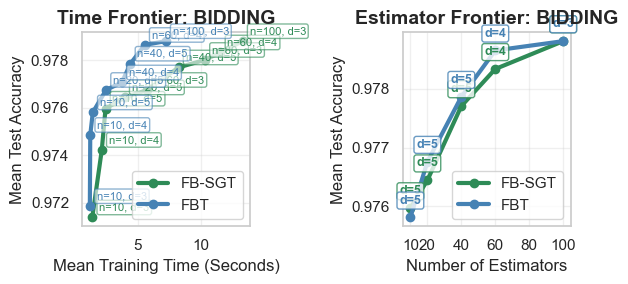

Generating frontiers for: MAGIC


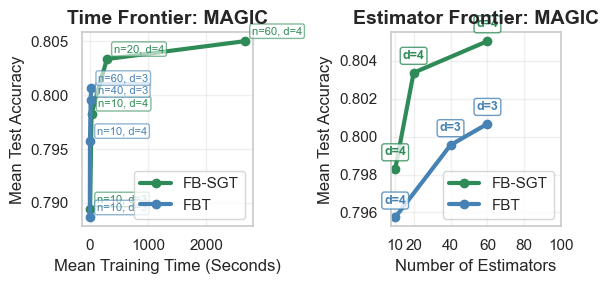

Generating frontiers for: RAISIN


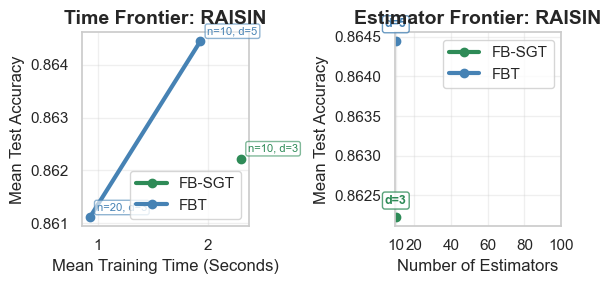

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure the dataframe is loaded (adjust path if needed)
# df = pd.read_csv("../processed_capability_results/capability_results.csv")

def generate_all_frontier_reports(df):
    datasets = df['dataset'].unique()
    colors = {'FBT': 'steelblue', 'FB-SGT': 'seagreen'}
    
    for dataset in datasets:
        print(f"Generating frontiers for: {dataset.upper()}")
        
        # 1. Setup the figure for this dataset (2 plots side-by-side)
        fig, (ax_time, ax_est) = plt.subplots(1, 2, figsize=(6, 3))
        
        # Filter and aggregate
        subset = df[df['dataset'] == dataset]
        agg_df = subset.groupby(['model', 'n_estimators', 'max_depth']).agg({
            'test_acc': 'mean', 
            'elapsed_time': 'mean'
        }).reset_index()

        # --- PLOT 1: Accuracy vs. Elapsed Time Frontier ---
        for model in agg_df['model'].unique():
            model_data = agg_df[agg_df['model'] == model].sort_values('elapsed_time')
            frontier_points = []
            current_max_acc = -np.inf
            for _, row in model_data.iterrows():
                if row['test_acc'] > current_max_acc:
                    frontier_points.append(row)
                    current_max_acc = row['test_acc']
            
            f_df = pd.DataFrame(frontier_points)
            ax_time.plot(f_df['elapsed_time'], f_df['test_acc'], label=f'{model}', 
                         color=colors[model], linewidth=3, marker='o')
            
            for _, row in f_df.iterrows():
                ax_time.annotate(f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}", 
                                 xy=(row['elapsed_time'], row['test_acc']), xytext=(5, 5),
                                 textcoords='offset points', fontsize=8, color=colors[model],
                                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec=colors[model]))

        ax_time.set_title(f"Time Frontier: {dataset.upper()}", fontsize=14, fontweight='bold')
        ax_time.set_xlabel("Mean Training Time (Seconds)")
        ax_time.set_ylabel("Mean Test Accuracy")
        ax_time.grid(True, alpha=0.3)
        ax_time.legend()

        # --- PLOT 2: Accuracy vs. N Estimators Frontier ---
        for model in agg_df['model'].unique():
            model_data = agg_df[agg_df['model'] == model].sort_values('n_estimators')
            frontier_points = []
            unique_n = sorted(model_data['n_estimators'].unique())
            current_max_acc = -np.inf
            
            for n in unique_n:
                options = model_data[model_data['n_estimators'] == n]
                best_row = options.loc[options['test_acc'].idxmax()]
                if best_row['test_acc'] >= current_max_acc:
                    frontier_points.append(best_row)
                    current_max_acc = best_row['test_acc']
            
            f_df = pd.DataFrame(frontier_points)
            ax_est.plot(f_df['n_estimators'], f_df['test_acc'], label=f'{model}', 
                        color=colors[model], linewidth=3, marker='o')
            
            for _, row in f_df.iterrows():
                ax_est.annotate(f"d={int(row['max_depth'])}", 
                                xy=(row['n_estimators'], row['test_acc']), xytext=(0, 10),
                                textcoords='offset points', ha='center', fontsize=9, 
                                fontweight='bold', color=colors[model],
                                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec=colors[model]))

        ax_est.set_title(f"Estimator Frontier: {dataset.upper()}", fontsize=14, fontweight='bold')
        ax_est.set_xlabel("Number of Estimators")
        ax_est.set_ylabel("Mean Test Accuracy")
        ax_est.grid(True, alpha=0.3)
        ax_est.set_xticks(sorted(agg_df['n_estimators'].unique()))
        ax_est.legend()

        plt.tight_layout()
        plt.show()

# Run the generator
generate_all_frontier_reports(df)

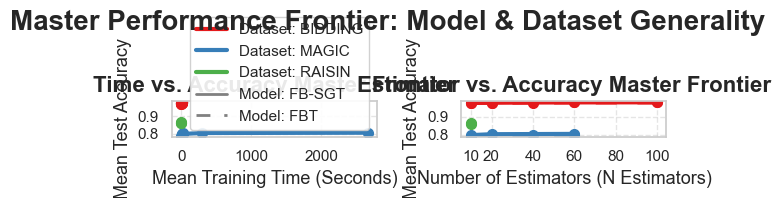

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

def generate_master_frontiers(df):
    # 1. Setup aesthetics
    sns.set_theme(style="whitegrid")
    
    datasets = sorted(df['dataset'].unique())
    # Fixed the color_palette attribute name
    dataset_colors = sns.color_palette("Set1", n_colors=len(datasets))
    
    # Textures/Line Styles for Models: FB-SGT is Solid, FBT is Dashed
    model_styles = {'FBT': (0, (5, 5)), 'FB-SGT': '-'} 
    
    fig, (ax_time, ax_est) = plt.subplots(1, 2, figsize=(6, 2), dpi=100)
    fig.suptitle("Master Performance Frontier: Model & Dataset Generality", fontsize=20, fontweight='bold', y=0.98)
    
    # Build a custom legend for clarity
    legend_elements = []

    # Iterate through Dataset/Color
    for ds_idx, dataset in enumerate(datasets):
        ds_color = dataset_colors[ds_idx]
        subset = df[df['dataset'] == dataset]
        
        # Aggregate to means (over folds/trials)
        agg_df = subset.groupby(['model', 'n_estimators', 'max_depth']).agg({
            'test_acc': 'mean', 
            'elapsed_time': 'mean'
        }).reset_index()

        # Add dataset color to legend
        legend_elements.append(Line2D([0], [0], color=ds_color, lw=3, label=f'Dataset: {dataset.upper()}'))
        
        # Iterate through Model/Style
        for model in agg_df['model'].unique():
            m_style = model_styles[model]
            
            # --- CALCULATE TIME FRONTIER ---
            model_data_time = agg_df[agg_df['model'] == model].sort_values('elapsed_time')
            frontier_time = []
            current_max_acc_t = -np.inf
            for _, row in model_data_time.iterrows():
                if row['test_acc'] > current_max_acc_t:
                    frontier_time.append(row)
                    current_max_acc_t = row['test_acc']
            f_df_time = pd.DataFrame(frontier_time)
            
            ax_time.plot(f_df_time['elapsed_time'], f_df_time['test_acc'], 
                         color=ds_color, linestyle=m_style, linewidth=3, marker='o', markersize=7)

            # --- CALCULATE EST FRONTIER ---
            model_data_est = agg_df[agg_df['model'] == model].sort_values('n_estimators')
            frontier_est = []
            unique_n = sorted(model_data_est['n_estimators'].unique())
            current_max_acc_e = -np.inf
            
            for n in unique_n:
                options = model_data_est[model_data_est['n_estimators'] == n]
                best_row = options.loc[options['test_acc'].idxmax()]
                if best_row['test_acc'] >= current_max_acc_e:
                    frontier_est.append(best_row)
                    current_max_acc_e = best_row['test_acc']
            f_df_est = pd.DataFrame(frontier_est)

            ax_est.plot(f_df_est['n_estimators'], f_df_est['test_acc'], 
                        color=ds_color, linestyle=m_style, linewidth=3, marker='o', markersize=7)

    # Adding Model Style definitions to the custom legend
    legend_elements.append(Line2D([0], [0], color='gray', lw=2, label='Model: FB-SGT', linestyle=model_styles['FB-SGT']))
    legend_elements.append(Line2D([0], [0], color='gray', lw=2, label='Model: FBT', linestyle=model_styles['FBT']))

    # --- PLOT 1: Time Frontier Aesthetics ---
    ax_time.set_title("Time vs. Accuracy Master Frontier", fontsize=16, fontweight='bold')
    ax_time.set_xlabel("Mean Training Time (Seconds)", fontsize=13)
    ax_time.set_ylabel("Mean Test Accuracy", fontsize=13)
    ax_time.grid(True, linestyle='--', alpha=0.5)

    # --- PLOT 2: Estimator Frontier Aesthetics ---
    ax_est.set_title("Estimator vs. Accuracy Master Frontier", fontsize=16, fontweight='bold')
    ax_est.set_xlabel("Number of Estimators (N Estimators)", fontsize=13)
    ax_est.set_ylabel("Mean Test Accuracy", fontsize=13)
    ax_est.grid(True, linestyle='--', alpha=0.5)
    ax_est.set_xticks(sorted(df['n_estimators'].unique()))
    
    # Unified legend
    ax_time.legend(handles=legend_elements, loc='best', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Run the plot
generate_master_frontiers(df)

## BZ New Plots for Thesis

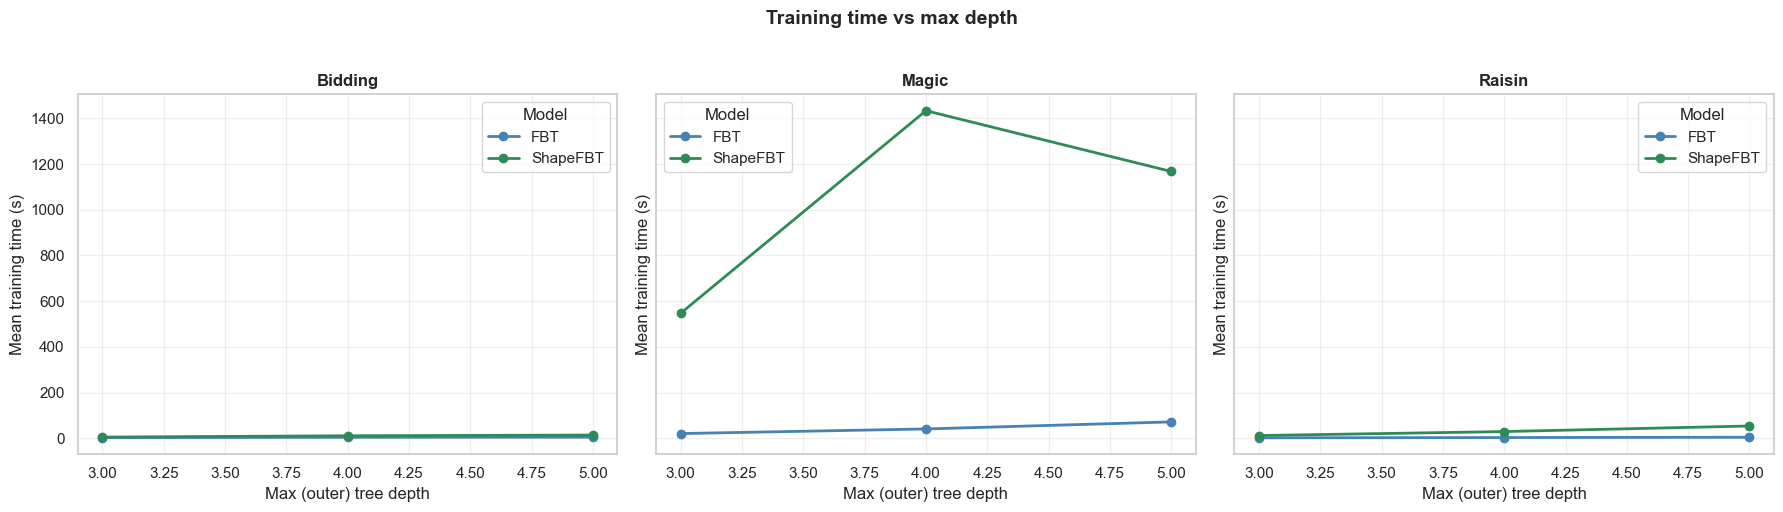

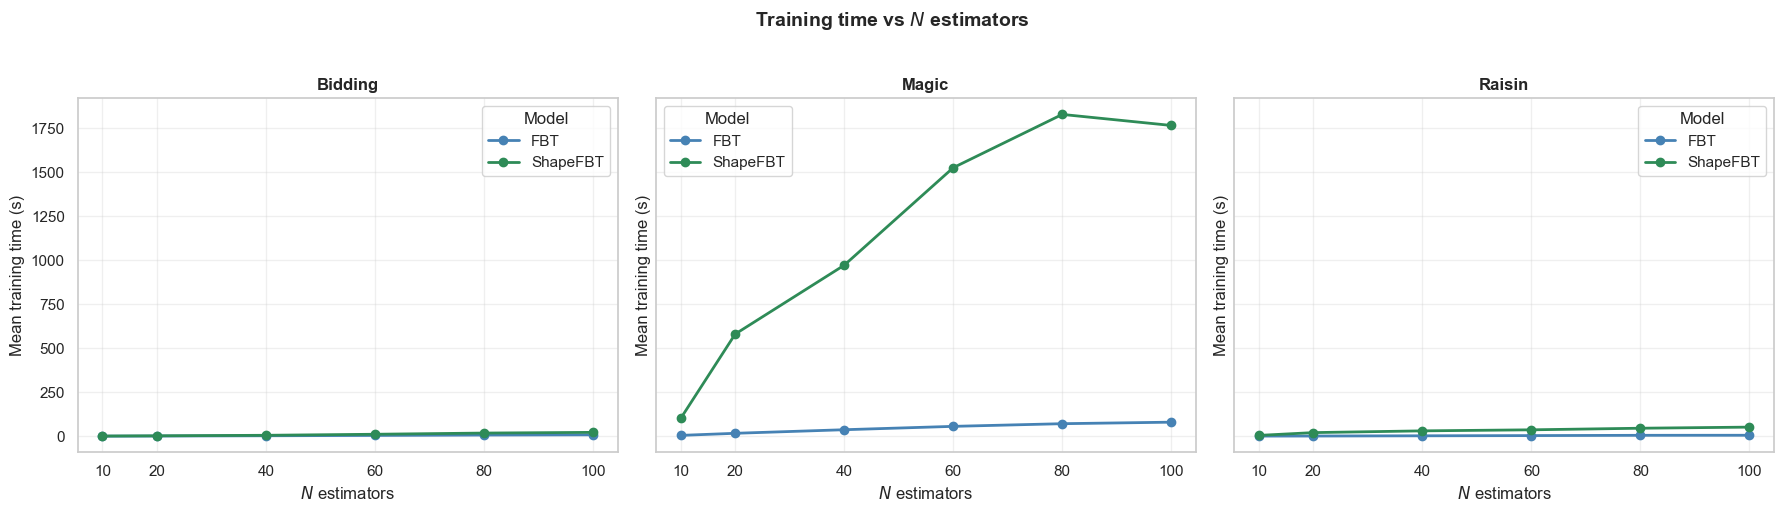

In [ ]:
# Mean training time vs max depth / n_estimators (one panel per dataset, one line per model).
# Averages over folds/trials; for each x-value the other hyperparameter is averaged out.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
colors = {"FBT": "steelblue", "FB-SGT": "seagreen"}

time_by_depth = (
    df.groupby(["dataset", "model", "max_depth"], as_index=False)["elapsed_time"]
    .mean()
    .sort_values(["dataset", "model", "max_depth"])
)
time_by_n = (
    df.groupby(["dataset", "model", "n_estimators"], as_index=False)["elapsed_time"]
    .mean()
    .sort_values(["dataset", "model", "n_estimators"])
)

# datasets = sorted(time_by_depth["dataset"].unique())
datasets = ['bidding', 'raisin']
fig1, axes1 = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes1 = [axes1]
for ax, ds in zip(axes1, datasets):
    sub = time_by_depth[time_by_depth["dataset"] == ds]
    for model in sorted(sub["model"].unique()):
        msub = sub[sub["model"] == model]
        ax.plot(
            msub["max_depth"],
            msub["elapsed_time"],
            marker="o",
            linewidth=2,
            label=model,
            color=colors.get(model),
        )
    ax.set_title(ds.capitalize(), fontweight="bold")
    ax.set_xlabel("Max (outer) tree depth")
    ax.set_ylabel("Mean training time (s)")
    ax.legend(title="Model")
    ax.grid(True, alpha=0.3)
fig1.suptitle("Training time vs max depth", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes2 = [axes2]
for ax, ds in zip(axes2, datasets):
    sub = time_by_n[time_by_n["dataset"] == ds]
    for model in sorted(sub["model"].unique()):
        msub = sub[sub["model"] == model]
        ax.plot(
            msub["n_estimators"],
            msub["elapsed_time"],
            marker="o",
            linewidth=2,
            label=model,
            color=colors.get(model),
        )
    ax.set_title(ds.capitalize(), fontweight="bold")
    ax.set_xlabel("$N$ estimators")
    ax.set_ylabel("Mean training time (s)")
    ax.legend(title="Model")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(sub["n_estimators"].unique()))
fig2.suptitle("Training time vs $N$ estimators", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

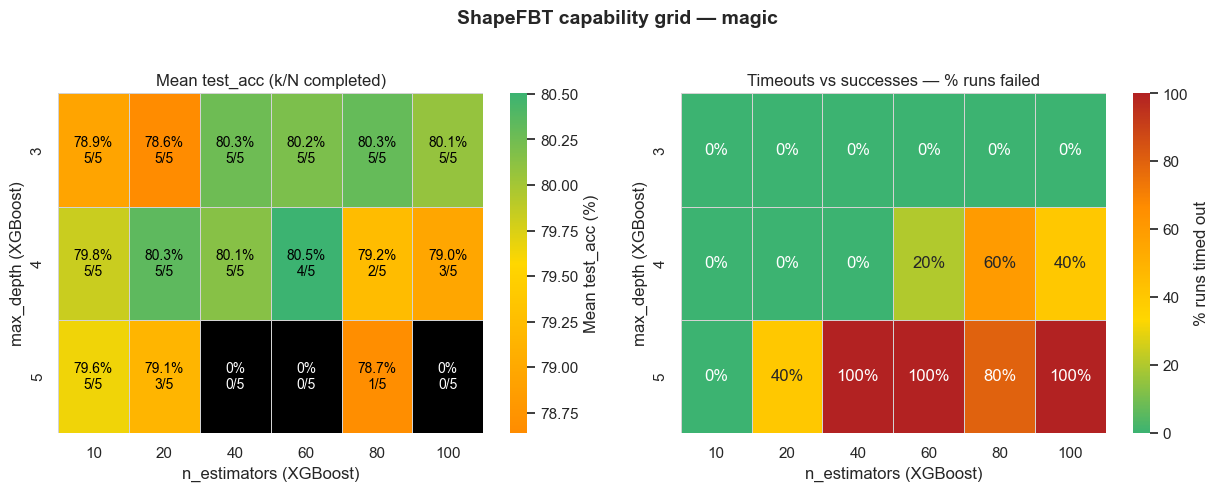

In [13]:
# FB-SGT capability: mean test acc (%) and timeout rate (%) per grid cell.
import glob
import json
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def load_shapefbt_capability_jsons(folder: str) -> pd.DataFrame:
    """Load all shapefbt_capability_*.json files from one dataset folder."""
    rows = []
    pattern = os.path.join(folder, "shapefbt_capability_*.json")
    for fp in glob.glob(pattern):
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
        train_acc = data.get("train_acc")
        if isinstance(train_acc, str) and train_acc.strip().lower() == "nan":
            ok = False
        elif isinstance(train_acc, float) and (train_acc != train_acc):  # NaN
            ok = False
        else:
            ok = True
        ta = data.get("test_acc")
        try:
            test_acc = float(ta) if ok else np.nan
        except (TypeError, ValueError):
            test_acc = np.nan
        rows.append(
            {
                "n_estimators": int(data["n_estimators"]),
                "max_depth": int(data["max_depth"]),
                "fold": int(data["fold"]),
                "success": ok,
                "test_acc": test_acc,
            }
        )
    return pd.DataFrame(rows)


def plot_shapefbt_success_heatmaps(
    dataset: str = "magic",
    results_root=None,
    metric_col: str = "test_acc",
):
    """
    Left: mean `metric_col` over successful runs (color scale in %); cells where
    all runs timed out are black with annotation 0% / 0/N.
    Right: % of runs that timed out per cell.
    """
    if results_root is None:
        results_root = os.path.join(
            "..", "capability_results", "shapefbt_capability_results", "results"
        )
    folder = os.path.join(results_root, dataset)
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Missing folder: {os.path.abspath(folder)}")

    df = load_shapefbt_capability_jsons(folder)
    if df.empty:
        print(f"No JSON files found under {folder}")
        return

    n_list = sorted(df["n_estimators"].unique())
    d_list = sorted(df["max_depth"].unique())

    mat_plot = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    mat_timeout_frac = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    annot_b = np.empty((len(d_list), len(n_list)), dtype=object)

    for i, d in enumerate(d_list):
        for j, n in enumerate(n_list):
            sub = df[(df["n_estimators"] == n) & (df["max_depth"] == d)]
            total = len(sub)
            k = int(sub["success"].sum()) if total else 0
            if total:
                mat_timeout_frac[i, j] = (total - k) / total
            if total == 0:
                mat_plot[i, j] = np.nan
                annot_b[i, j] = "—"
            elif k == 0:
                # All folds timed out: black cell, 0% / 0/N
                mat_plot[i, j] = -1.0
                annot_b[i, j] = f"0%\n0/{total}"
            else:
                m = sub.loc[sub["success"], metric_col].mean()
                mat_plot[i, j] = m * 100.0
                annot_b[i, j] = f"{m * 100:.1f}%\n{k}/{total}"

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

    # --- CUSTOM COLORMAPS ---
    # Left Map (Accuracy): Orange (Low) -> Yellow (Mid) -> Green (High)
    cmap_left_base = mcolors.LinearSegmentedColormap.from_list(
        "acc_cmap", ["darkorange", "gold", "mediumseagreen"]
    )
    cmap_left = cmap_left_base.copy()
    cmap_left.set_under("black")

    # Right Map (Timeouts): Green (0%) -> Yellow (Mid) -> Orange/Red (100%)
    cmap_right = mcolors.LinearSegmentedColormap.from_list(
        "timeout_cmap", ["mediumseagreen", "gold", "darkorange", "firebrick"]
    )

    # Mean metric (%): -1 => black (cmap.set_under), NaN => masked
    mask_b = np.isnan(mat_plot)
    valid_pct = mat_plot[~np.isnan(mat_plot) & (mat_plot >= 0)]
    
    # Dynamically set vmin and vmax based ONLY on valid successful runs
    if valid_pct.size > 0:
        vmin_val = float(np.min(valid_pct))
        vmax_val = float(np.max(valid_pct))
    else:
        vmin_val = 0.0
        vmax_val = 100.0

    sns.heatmap(
        mat_plot,
        ax=axes[0],
        mask=mask_b,
        annot=False,
        cmap=cmap_left,
        vmin=vmin_val,  
        vmax=vmax_val,  
        linewidths=0.5,
        linecolor='lightgray',
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": f"Mean {metric_col} (%)"},
    )

    for i in range(len(d_list)):
        for j in range(len(n_list)):
            if mask_b[i, j]:
                continue
            txt = annot_b[i, j]
            # Since the custom gradient colors are fairly bright, black text works best everywhere except the black cells
            tcolor = "white" if mat_plot[i, j] == -1.0 else "black"
            
            axes[0].text(
                j + 0.5,
                i + 0.5,
                txt,
                ha="center",
                va="center",
                color=tcolor,
                fontsize=10,
            )

    axes[0].set_xlabel("n_estimators (XGBoost)")
    axes[0].set_ylabel("max_depth (XGBoost)")
    axes[0].set_title(f"Mean {metric_col} (k/N completed)")

    # % timed out per cell
    mat_timeout_pct = mat_timeout_frac * 100.0
    annot_timeout = np.empty_like(mat_timeout_pct, dtype=object)
    for ii in range(mat_timeout_pct.shape[0]):
        for jj in range(mat_timeout_pct.shape[1]):
            v = mat_timeout_pct[ii, jj]
            annot_timeout[ii, jj] = "" if (v != v) else f"{v:.0f}%"

    sns.heatmap(
        mat_timeout_pct,
        ax=axes[1],
        annot=annot_timeout,
        fmt="",
        cmap=cmap_right,          # Applied custom timeout colormap here
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor='lightgray',
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": "% runs timed out"},
    )
    axes[1].set_xlabel("n_estimators (XGBoost)")
    axes[1].set_ylabel("max_depth (XGBoost)")
    axes[1].set_title("Timeouts vs successes — % runs failed")

    plt.suptitle(f"FB-SGT capability grid — {dataset}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# Default: MAGIC (change dataset name to compare raisin / bidding)
plot_shapefbt_success_heatmaps(dataset="magic")

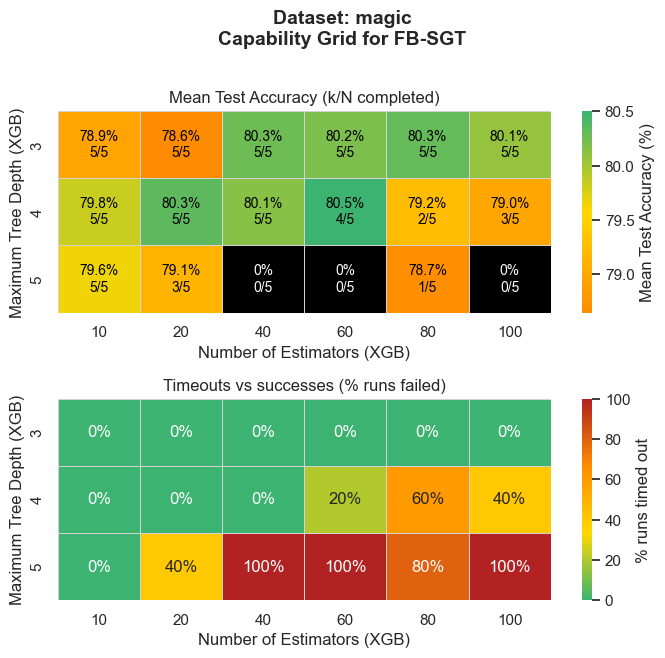

In [13]:
# FB-SGT capability heatmaps — vertical layout (2 rows × 1 column)
import glob
import json
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def load_shapefbt_capability_jsons(folder: str) -> pd.DataFrame:
    """Load all shapefbt_capability_*.json files from one dataset folder."""
    rows = []
    pattern = os.path.join(folder, "shapefbt_capability_*.json")
    for fp in glob.glob(pattern):
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
        train_acc = data.get("train_acc")
        if isinstance(train_acc, str) and train_acc.strip().lower() == "nan":
            ok = False
        elif isinstance(train_acc, float) and (train_acc != train_acc):
            ok = False
        else:
            ok = True
        ta = data.get("test_acc")
        try:
            test_acc = float(ta) if ok else np.nan
        except (TypeError, ValueError):
            test_acc = np.nan
        rows.append(
            {
                "n_estimators": int(data["n_estimators"]),
                "max_depth": int(data["max_depth"]),
                "fold": int(data["fold"]),
                "success": ok,
                "test_acc": test_acc,
            }
        )
    return pd.DataFrame(rows)


def plot_shapefbt_success_heatmaps_vertical(
    dataset: str = "magic",
    results_root=None,
    metric_col: str = "test_acc",
    model_name: str = "FB-SGT",
):
    """
    Same data as `plot_shapefbt_success_heatmaps`, but panels are stacked:
    top = mean metric, bottom = % timed out.
    """
    if results_root is None:
        results_root = os.path.join(
            "..", "capability_results", "shapefbt_capability_results", "results"
        )
    folder = os.path.join(results_root, dataset)
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Missing folder: {os.path.abspath(folder)}")

    df = load_shapefbt_capability_jsons(folder)
    if df.empty:
        print(f"No JSON files found under {folder}")
        return

    n_list = sorted(df["n_estimators"].unique())
    d_list = sorted(df["max_depth"].unique())

    mat_plot = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    mat_timeout_frac = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    annot_b = np.empty((len(d_list), len(n_list)), dtype=object)

    for i, d in enumerate(d_list):
        for j, n in enumerate(n_list):
            sub = df[(df["n_estimators"] == n) & (df["max_depth"] == d)]
            total = len(sub)
            k = int(sub["success"].sum()) if total else 0
            if total:
                mat_timeout_frac[i, j] = (total - k) / total
            if total == 0:
                mat_plot[i, j] = np.nan
                annot_b[i, j] = "—"
            elif k == 0:
                mat_plot[i, j] = -1.0
                annot_b[i, j] = f"0%\n0/{total}"
            else:
                m = sub.loc[sub["success"], metric_col].mean()
                mat_plot[i, j] = m * 100.0
                annot_b[i, j] = f"{m * 100:.1f}%\n{k}/{total}"

    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5))

    cmap_left_base = mcolors.LinearSegmentedColormap.from_list(
        "acc_cmap", ["darkorange", "gold", "mediumseagreen"]
    )
    cmap_left = cmap_left_base.copy()
    cmap_left.set_under("black")

    cmap_right = mcolors.LinearSegmentedColormap.from_list(
        "timeout_cmap", ["mediumseagreen", "gold", "darkorange", "firebrick"]
    )

    mask_b = np.isnan(mat_plot)
    valid_pct = mat_plot[~np.isnan(mat_plot) & (mat_plot >= 0)]

    if valid_pct.size > 0:
        vmin_val = float(np.min(valid_pct))
        vmax_val = float(np.max(valid_pct))
    else:
        vmin_val = 0.0
        vmax_val = 100.0

    sns.heatmap(
        mat_plot,
        ax=axes[0],
        mask=mask_b,
        annot=False,
        cmap=cmap_left,
        vmin=vmin_val,
        vmax=vmax_val,
        linewidths=0.5,
        linecolor="lightgray",
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": f"Mean Test Accuracy (%)"},
        # cbar_kws={"label": f"Mean {metric_col} (%)"},
    )

    for i in range(len(d_list)):
        for j in range(len(n_list)):
            if mask_b[i, j]:
                continue
            txt = annot_b[i, j]
            tcolor = "white" if mat_plot[i, j] == -1.0 else "black"
            axes[0].text(
                j + 0.5,
                i + 0.5,
                txt,
                ha="center",
                va="center",
                color=tcolor,
                fontsize=10,
            )

    axes[0].set_xlabel("Number of Estimators (XGB)")
    axes[0].set_ylabel("Maximum Tree Depth (XGB)")
    # axes[0].set_title(f"Mean {metric_col} (k/N completed)")
    axes[0].set_title(f"Mean Test Accuracy (k/N completed)")

    mat_timeout_pct = mat_timeout_frac * 100.0
    annot_timeout = np.empty_like(mat_timeout_pct, dtype=object)
    for ii in range(mat_timeout_pct.shape[0]):
        for jj in range(mat_timeout_pct.shape[1]):
            v = mat_timeout_pct[ii, jj]
            annot_timeout[ii, jj] = "" if (v != v) else f"{v:.0f}%"

    sns.heatmap(
        mat_timeout_pct,
        ax=axes[1],
        annot=annot_timeout,
        fmt="",
        cmap=cmap_right,
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="lightgray",
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": "% runs timed out"},
    )
    axes[1].set_xlabel("Number of Estimators (XGB)")
    axes[1].set_ylabel("Maximum Tree Depth (XGB)")
    axes[1].set_title("Timeouts vs successes (% runs failed)")

    plt.suptitle(f"Dataset: {dataset}\nCapability Grid for {model_name}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_shapefbt_success_heatmaps_vertical(dataset="magic")


In [ ]:
plot_shapefbt_success_heatmaps_vertical(dataset="magic")


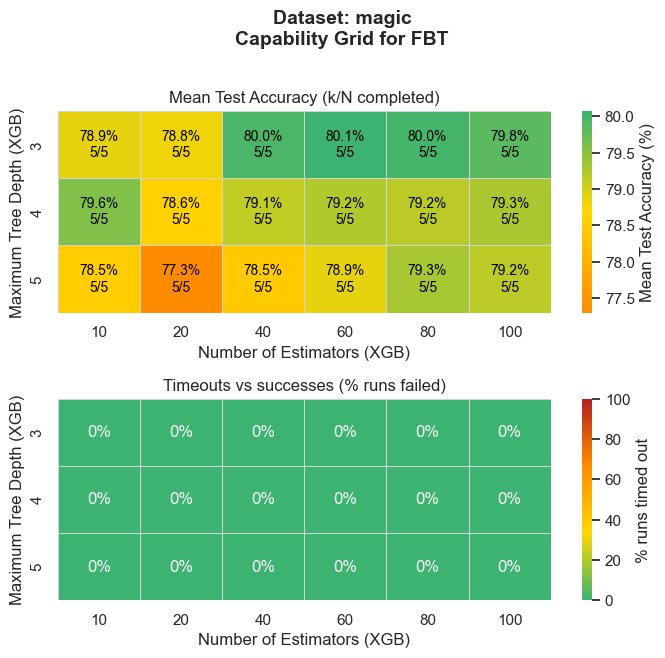

In [25]:
# Capability heatmaps (vertical 2×1) — FB-SGT or FBT via `student=`
# Same JSON schema as shapefbt_capability_*.json / fbt_capability_*.json.
# Paths under ../capability_results/:
#   FB-SGT: <shapefbt_bundle>/results/<dataset>/
#   FBT:    <fbt_bundle>/<dataset>/   (no extra `results` level)

import glob
import json
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Optional

sns.set_theme(style="whitegrid")

# (folder under capability_results, json glob basename, use `results/<dataset>` vs `<dataset>`)
STUDENT_CAPABILITY = {
    "FB-SGT": ("shapefbt_capability_results", "shapefbt_capability_*.json", True),
    "FBT": ("fbt_capability_results", "fbt_capability_*.json", False),
}


def _normalize_student(student: str) -> str:
    s = (student or "").strip()
    if s in STUDENT_CAPABILITY:
        return s
    u = s.upper().replace(" ", "").replace("_", "")
    if u == "FBT":
        return "FBT"
    if u in ("FB-SGT", "FBSGT", "SHAPEFBT"):
        return "FB-SGT"
    raise ValueError(
        f"Unknown student {student!r}. Use 'FB-SGT' or 'FBT' (aliases: FBSGT, ShapeFBT)."
    )


def load_capability_jsons(folder: str, json_glob: str) -> pd.DataFrame:
    rows = []
    pattern = os.path.join(folder, json_glob)
    for fp in glob.glob(pattern):
        with open(fp, encoding="utf-8") as f:
            data = json.load(f)
        train_acc = data.get("train_acc")
        if isinstance(train_acc, str) and train_acc.strip().lower() == "nan":
            ok = False
        elif isinstance(train_acc, float) and (train_acc != train_acc):
            ok = False
        else:
            ok = True
        ta = data.get("test_acc")
        try:
            test_acc = float(ta) if ok else np.nan
        except (TypeError, ValueError):
            test_acc = np.nan
        rows.append(
            {
                "n_estimators": int(data["n_estimators"]),
                "max_depth": int(data["max_depth"]),
                "fold": int(data["fold"]),
                "success": ok,
                "test_acc": test_acc,
            }
        )
    return pd.DataFrame(rows)


def plot_capability_success_heatmaps_vertical(
    dataset: str = "magic",
    student: str = "FB-SGT",
    capability_root: Optional[str] = None,
    metric_col: str = "test_acc",
    model_name: Optional[str] = None,
):
    """
    Stacked heatmaps: mean test accuracy (top), % runs timed out (bottom).

    Parameters
    ----------
    student : str
        'FB-SGT' (shapefbt JSONs) or 'FBT' (fbt JSONs).
    model_name : str, optional
        Suptitle label; defaults to the normalized `student` string.
    capability_root : str, optional
        Parent of the bundle folders. Default: ../capability_results
    """
    key = _normalize_student(student)
    bundle, json_glob, use_results_subdir = STUDENT_CAPABILITY[key]
    if capability_root is None:
        capability_root = os.path.join("..", "capability_results")
    if use_results_subdir:
        folder = os.path.join(capability_root, bundle, "results", dataset)
    else:
        folder = os.path.join(capability_root, bundle, dataset)
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Missing folder: {os.path.abspath(folder)}")

    display_name = model_name if model_name is not None else key
    df = load_capability_jsons(folder, json_glob)
    if df.empty:
        print(f"No JSON files matching {json_glob!r} under {folder}")
        return

    n_list = sorted(df["n_estimators"].unique())
    d_list = sorted(df["max_depth"].unique())

    mat_plot = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    mat_timeout_frac = np.full((len(d_list), len(n_list)), np.nan, dtype=float)
    annot_b = np.empty((len(d_list), len(n_list)), dtype=object)

    for i, d in enumerate(d_list):
        for j, n in enumerate(n_list):
            sub = df[(df["n_estimators"] == n) & (df["max_depth"] == d)]
            total = len(sub)
            k = int(sub["success"].sum()) if total else 0
            if total:
                mat_timeout_frac[i, j] = (total - k) / total
            if total == 0:
                mat_plot[i, j] = np.nan
                annot_b[i, j] = "—"
            elif k == 0:
                mat_plot[i, j] = -1.0
                annot_b[i, j] = f"0%\n0/{total}"
            else:
                m = sub.loc[sub["success"], metric_col].mean()
                mat_plot[i, j] = m * 100.0
                annot_b[i, j] = f"{m * 100:.1f}%\n{k}/{total}"

    fig, axes = plt.subplots(2, 1, figsize=(7, 6.5))

    cmap_left_base = mcolors.LinearSegmentedColormap.from_list(
        "acc_cmap", ["darkorange", "gold", "mediumseagreen"]
    )
    cmap_left = cmap_left_base.copy()
    cmap_left.set_under("black")

    cmap_right = mcolors.LinearSegmentedColormap.from_list(
        "timeout_cmap", ["mediumseagreen", "gold", "darkorange", "firebrick"]
    )

    mask_b = np.isnan(mat_plot)
    valid_pct = mat_plot[~np.isnan(mat_plot) & (mat_plot >= 0)]

    if valid_pct.size > 0:
        vmin_val = float(np.min(valid_pct))
        vmax_val = float(np.max(valid_pct))
    else:
        vmin_val = 0.0
        vmax_val = 100.0

    sns.heatmap(
        mat_plot,
        ax=axes[0],
        mask=mask_b,
        annot=False,
        cmap=cmap_left,
        vmin=vmin_val,
        vmax=vmax_val,
        linewidths=0.5,
        linecolor="lightgray",
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": "Mean Test Accuracy (%)"},
    )

    for i in range(len(d_list)):
        for j in range(len(n_list)):
            if mask_b[i, j]:
                continue
            txt = annot_b[i, j]
            tcolor = "white" if mat_plot[i, j] == -1.0 else "black"
            axes[0].text(
                j + 0.5,
                i + 0.5,
                txt,
                ha="center",
                va="center",
                color=tcolor,
                fontsize=10,
            )

    axes[0].set_xlabel("Number of Estimators (XGB)")
    axes[0].set_ylabel("Maximum Tree Depth (XGB)")
    axes[0].set_title("Mean Test Accuracy (k/N completed)")

    mat_timeout_pct = mat_timeout_frac * 100.0
    annot_timeout = np.empty_like(mat_timeout_pct, dtype=object)
    for ii in range(mat_timeout_pct.shape[0]):
        for jj in range(mat_timeout_pct.shape[1]):
            v = mat_timeout_pct[ii, jj]
            annot_timeout[ii, jj] = "" if (v != v) else f"{v:.0f}%"

    sns.heatmap(
        mat_timeout_pct,
        ax=axes[1],
        annot=annot_timeout,
        fmt="",
        cmap=cmap_right,
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="lightgray",
        xticklabels=n_list,
        yticklabels=d_list,
        cbar_kws={"label": "% runs timed out"},
    )
    axes[1].set_xlabel("Number of Estimators (XGB)")
    axes[1].set_ylabel("Maximum Tree Depth (XGB)")
    axes[1].set_title("Timeouts vs successes (% runs failed)")

    plt.suptitle(
        f"Dataset: {dataset}\nCapability Grid for {display_name}",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


# Examples (uncomment or duplicate as needed):
# plot_capability_success_heatmaps_vertical(dataset="magic", student="FB-SGT")
plot_capability_success_heatmaps_vertical(dataset="magic", student="FBT")
